Laenge: 912 
Breite: 624 
Dicke: 3.6
Auflager: Min
cos:  1.0
q = 0.024525
D = 6159152.500615914
maxh: 30
min w [mm]        = -7.13707426570384
max w [mm]        = 0.04927728025235405
max z-Abstand [mm]= 7.186351545956194
max |w| [mm]      = 7.13707426570384
Scale in Visualization:  100


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Vectors': False…

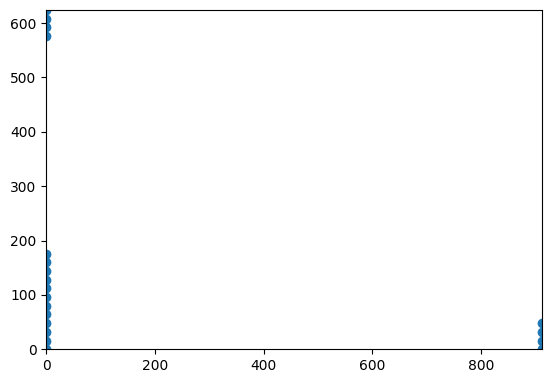

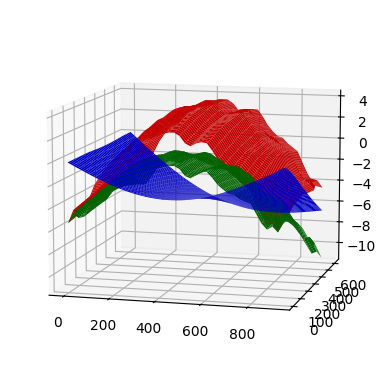

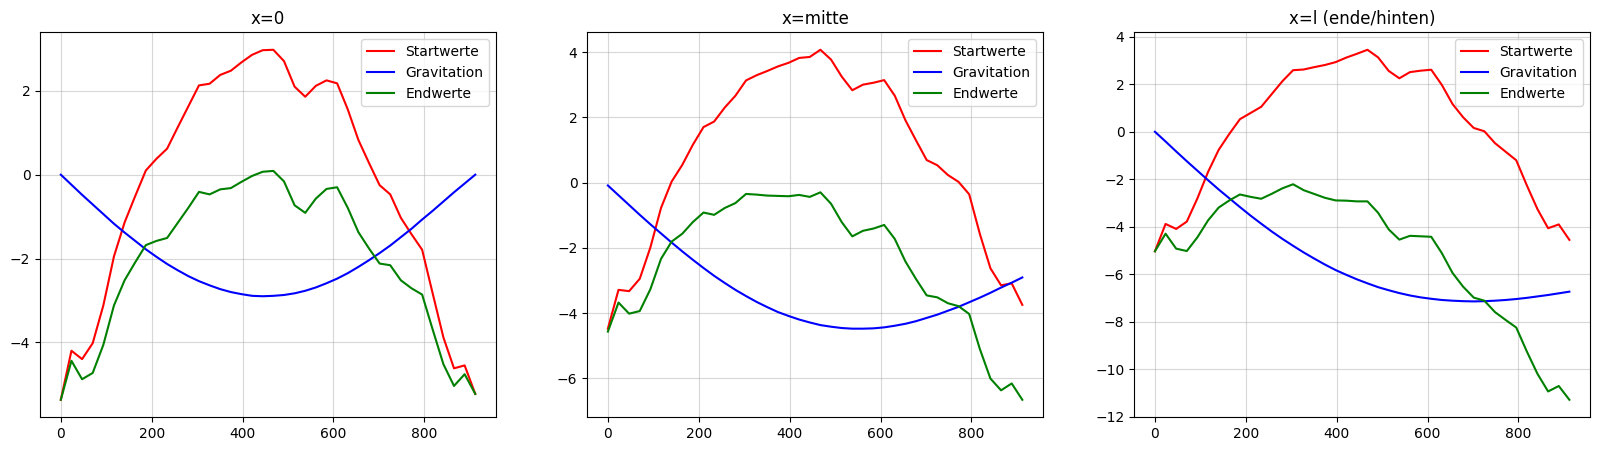

In [2]:
import numpy as np
from math import sqrt, pi, cos
import xyzFile_zusammenrechnen_EW   # greift auf *.py file zu, nicht auf *.ipynb
import HC_AuflagerMinima
import pyvista as pv
pv.set_jupyter_backend('trame')

import import_ipynb
import RM_nVex_AKTUELL
# def gravitationsEinfluss_Auflager(l,b,t,step,auflager_liste,radius):

"""
15.5
Reissner Mindlin ohne TDNNS
nearest Vertex -> simply supported bei analysierten Punktauflager

1. nimmt Messwerte.xyz file
2. analysiert Auflagerpunkte + tol
3. berechnet gravitation mit RM_nVex_AKTUELL
4. zusammenrechnen und simulieren
"""
t = 3.6
tolMinima = 0.5
Vorzeichen = "Min"
# Vorzeichen = "Max"

# MESSWERTE
#filename_MW = f"{t}mm_messwerte.xyz"
filename_MW = "xyzFiles/2026-04-05_13h25m24s_scan25-3.6.xyz"
data_messwerte = np.loadtxt(filename_MW)

# step wird aus Messwerte-File entnommen
step_square = len(data_messwerte[:,0])
if sqrt(step_square)%1 != 0:
    raise ValueError("the Length of the *.xyz-File is not suitable, it should be step*step")

step = int(sqrt(step_square))

# Laenge/Breite wird aus Messwerte-File entnommen
l = int(data_messwerte[-1,0])   #achtung: -1 steht hier für die letzte Zeile, 0 für den x eintrag, 1 für den y eintrag
b = int(data_messwerte[-1,1])
print("Laenge:",l,"\nBreite:",b,"\nDicke:",t)
print("Auflager:",Vorzeichen)
# r = 35
# r = l/40
r = l*b/40000 # mm    # Radius der Auflager, proportional zu den Maßen der Glasplatte 

#region AUFLAGER total
"""
AuflagerMinima definiert die Mittelpunkte der Auflager-Kreise, indem es den minimalen Z-wert sucht, 
danach alle z-werte sucht, die in einem gewissen Toleranz-bereich liegen und diese als Auflager-Punkte definiert

moegliches Problem: 
die punkte liegen nur in einem kleinen teilgebiet, obwohl auch noch ein anderer auflagerpunkt existiert, 
der aber wegen zu kleiner toleranz nicht gefunden wird
"""
auflager_liste = HC_AuflagerMinima.AuflagerMaxMin(t,tolMinima,filename_MW,Vorzeichen)
#endregion

scale = 100
maxh = 30

Neigungswinkel_grad = 0 # Gradz
Neigungswinkel_rad = Neigungswinkel_grad * pi/180
Neigungsfaktor_cos = cos(Neigungswinkel_rad)
print("cos: ",Neigungsfaktor_cos)

filename_GRAV = RM_nVex_AKTUELL.ReissnerMindlin_GRAV_Punkte(l,b,t,auflager_liste,scale,step,maxh,Neigungsfaktor_cos)

filename_EW = xyzFile_zusammenrechnen_EW.plotten(l,b,t,step,filename_MW,filename_GRAV,Vorzeichen)